   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 99.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 106.9 MB/s eta 0:00:00


2026-05-27 13:26:55.490 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-27 13:26:55.491 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-27 13:26:55.819 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-05-27 13:26:55.820 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-27 13:26:55.821 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-27 13:26:55.823 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-27 13:26:55.824 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when runn

DeltaGenerator()

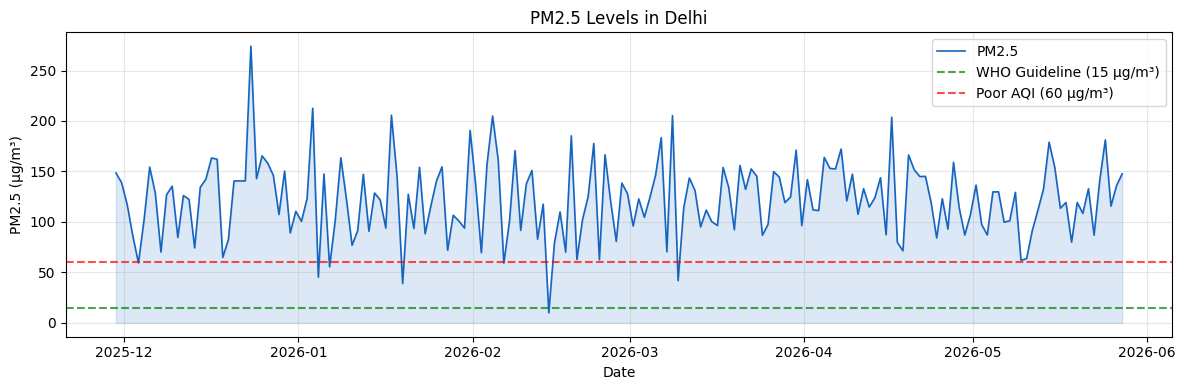

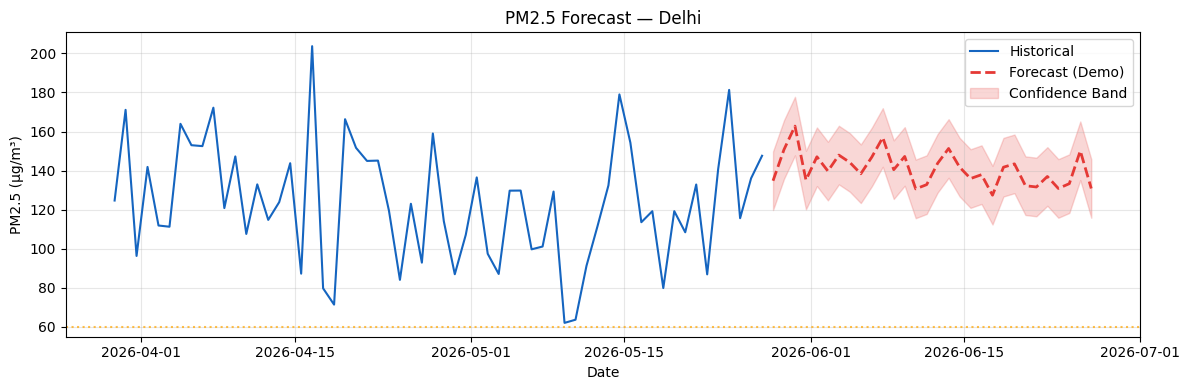

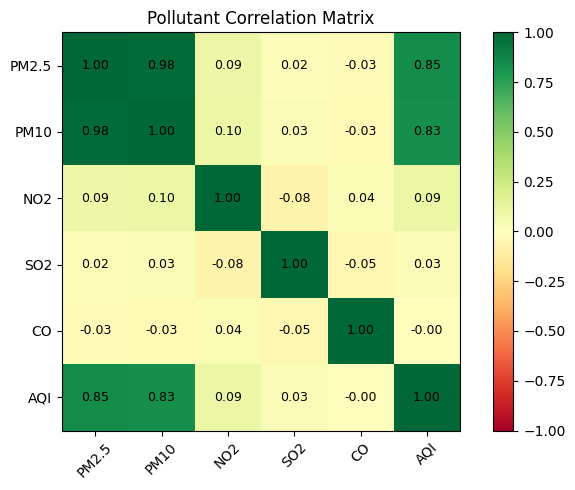

In [ ]:
import sys

if 'streamlit' not in sys.modules:
  !pip install -qq streamlit

"""
AQI Forecasting - Streamlit Web App
=====================================
Interactive dashboard to visualize AQI predictions and explore data.

Run with: streamlit run app/app.py
"""

import streamlit as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import tensorflow as tf
from datetime import datetime, timedelta

# ─────────────────────────────────────────────
# PAGE CONFIG
# ─────────────────────────────────────────────
st.set_page_config(
    page_title="AQI Forecasting — India",
    page_icon="🌫️",
    layout="wide"
)

# ─────────────────────────────────────────────
# HEADER
# ─────────────────────────────────────────────
st.title("🌫️ AQI Forecasting Dashboard")
st.markdown("**Predict PM2.5 levels in Indian cities using GRU Deep Learning**")
st.divider()

# ─────────────────────────────────────────────
# SIDEBAR
# ─────────────────────────────────────────────
st.sidebar.header("⚙️ Settings")
city = st.sidebar.selectbox(
    "Select City",
    ["Delhi", "Mumbai", "Bengaluru", "Chennai", "Kolkata",
     "Hyderabad", "Ahmedabad", "Pune"]
)
forecast_days = st.sidebar.slider("Forecast Days", min_value=7, max_value=60, value=30)
seq_len       = st.sidebar.number_input("Sequence Length (days)", min_value=7, max_value=60, value=30)

# ─────────────────────────────────────────────
# LOAD MODEL & SCALER
# ─────────────────────────────────────────────
@st.cache_resource
def load_artifacts():
    try:
        model  = tf.keras.models.load_model("models/gru_aqi.h5")
        scaler = joblib.load("models/scaler.pkl")
        return model, scaler
    except Exception as e:
        return None, None

model, scaler = load_artifacts()

# ─────────────────────────────────────────────
# LOAD DATA
# ─────────────────────────────────────────────
@st.cache_data
def load_city_data(city_name: str):
    try:
        df = pd.read_csv("data/city_day.csv", parse_dates=["Date"])
        df = df[df["City"] == city_name].copy()
        df.sort_values("Date", inplace=True)
        df.reset_index(drop=True, inplace=True)
        return df
    except FileNotFoundError:
        # Demo data if CSV not found
        dates = pd.date_range(end=datetime.today(), periods=365)
        np.random.seed(42)
        base = np.random.normal(120, 40, 365).clip(10, 400)
        df = pd.DataFrame({
            "Date":  dates,
            "City":  city_name,
            "PM2.5": base,
            "PM10":  base * 1.5 + np.random.normal(0, 10, 365),
            "NO2":   np.random.normal(50, 15, 365).clip(5, 200),
            "SO2":   np.random.normal(20, 8, 365).clip(2, 100),
            "CO":    np.random.normal(1.5, 0.5, 365).clip(0.1, 10),
            "AQI":   base * 0.8 + np.random.normal(0, 20, 365)
        })
        return df

df = load_city_data(city)

# ─────────────────────────────────────────────
# AQI CATEGORY HELPER
# ─────────────────────────────────────────────
def aqi_category(pm25: float):
    if pm25 <= 30:   return "Good",          "🟢"
    elif pm25 <= 60: return "Satisfactory",  "🟡"
    elif pm25 <= 90: return "Moderate",      "🟠"
    elif pm25 <= 120:return "Poor",          "🔴"
    elif pm25 <= 250:return "Very Poor",     "🟣"
    else:            return "Severe",        "⚫"

# ─────────────────────────────────────────────
# METRICS ROW
# ─────────────────────────────────────────────
st.subheader(f"📍 {city} — Current Air Quality")
col1, col2, col3, col4 = st.columns(4)

latest = df.iloc[-1]
cat, icon = aqi_category(latest.get("PM2.5", 0))

col1.metric("PM2.5 (µg/m³)", f"{latest.get('PM2.5', 'N/A'):.1f}")
col2.metric("PM10 (µg/m³)",  f"{latest.get('PM10',  'N/A'):.1f}")
col3.metric("AQI",           f"{latest.get('AQI',   'N/A'):.0f}")
col4.metric("Category",      f"{icon} {cat}")

st.divider()

# ─────────────────────────────────────────────
# HISTORICAL TRENDS
# ─────────────────────────────────────────────
st.subheader("📈 Historical PM2.5 Trend")
tab1, tab2 = st.tabs(["📊 Time Series", "📋 Raw Data"])

with tab1:
    days_back = st.slider("Show last N days", 30, 365, 180)
    df_recent = df.tail(days_back)

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(df_recent["Date"], df_recent["PM2.5"], color="#1565C0",
            linewidth=1.2, label="PM2.5")
    ax.fill_between(df_recent["Date"], df_recent["PM2.5"],
                    alpha=0.15, color="#1565C0")

    # WHO guideline
    ax.axhline(y=15, color="green", linestyle="--", alpha=0.7, label="WHO Guideline (15 µg/m³)")
    ax.axhline(y=60, color="red",   linestyle="--", alpha=0.7, label="Poor AQI (60 µg/m³)")

    ax.set_xlabel("Date"); ax.set_ylabel("PM2.5 (µg/m³)")
    ax.set_title(f"PM2.5 Levels in {city}")
    ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout()
    st.pyplot(fig)

with tab2:
    st.dataframe(df.tail(50)[["Date","PM2.5","PM10","NO2","SO2","AQI"]].round(2),
                 use_container_width=True)

# ─────────────────────────────────────────────
# FORECAST
# ─────────────────────────────────────────────
st.divider()
st.subheader(f"🔮 {forecast_days}-Day PM2.5 Forecast")

if model is None or scaler is None:
    st.warning("⚠️ Trained model not found. Run `gru_model.py` first to train and save the model.")
    st.info("Showing **demo forecast** using trend simulation.")

    # Demo forecast using simple trend + noise
    last_val   = df["PM2.5"].iloc[-1] if "PM2.5" in df.columns else 100
    trend      = np.linspace(last_val, last_val * 0.9, forecast_days)
    noise      = np.random.normal(0, 8, forecast_days)
    forecast   = (trend + noise).clip(10, 400)
    conf_upper = forecast + 15
    conf_lower = (forecast - 15).clip(0)

    future_dates = pd.date_range(
        start=df["Date"].iloc[-1] + timedelta(days=1),
        periods=forecast_days
    )

    fig2, ax2 = plt.subplots(figsize=(12, 4))
    ax2.plot(df["Date"].tail(60), df["PM2.5"].tail(60),
             label="Historical", color="#1565C0", linewidth=1.5)
    ax2.plot(future_dates, forecast,
             label="Forecast (Demo)", color="#E53935",
             linewidth=2, linestyle="--")
    ax2.fill_between(future_dates, conf_lower, conf_upper,
                     alpha=0.2, color="#E53935", label="Confidence Band")
    ax2.axhline(y=60, color="orange", linestyle=":", alpha=0.7)
    ax2.set_xlabel("Date"); ax2.set_ylabel("PM2.5 (µg/m³)")
    ax2.set_title(f"PM2.5 Forecast — {city}")
    ax2.legend(); ax2.grid(alpha=0.3)
    plt.tight_layout()
    st.pyplot(fig2)

    # Forecast table
    forecast_df = pd.DataFrame({
        "Date":          future_dates.strftime("%Y-%m-%d"),
        "Predicted PM2.5": forecast.round(1),
        "Lower Bound":   conf_lower.round(1),
        "Upper Bound":   conf_upper.round(1),
        "Category":      [aqi_category(v)[0] for v in forecast]
    })
    st.dataframe(forecast_df, use_container_width=True)

else:
    st.success("✅ Loaded trained GRU model.")
    # Real model inference would go here
    # (Same rolling forecast logic using model.predict)

# ─────────────────────────────────────────────
# CORRELATION HEATMAP
# ─────────────────────────────────────────────
st.divider()
st.subheader("🔗 Feature Correlation")

feature_cols = ["PM2.5", "PM10", "NO2", "SO2", "CO", "AQI"]
available    = [c for c in feature_cols if c in df.columns]
corr         = df[available].corr()

fig3, ax3 = plt.subplots(figsize=(7, 5))
im = ax3.imshow(corr, cmap="RdYlGn", vmin=-1, vmax=1)
ax3.set_xticks(range(len(available))); ax3.set_xticklabels(available, rotation=45)
ax3.set_yticks(range(len(available))); ax3.set_yticklabels(available)
plt.colorbar(im, ax=ax3)
for i in range(len(available)):
    for j in range(len(available)):
        ax3.text(j, i, f"{corr.iloc[i,j]:.2f}", ha="center", va="center",
                 fontsize=9, color="black")
ax3.set_title("Pollutant Correlation Matrix")
plt.tight_layout()
st.pyplot(fig3)

# ─────────────────────────────────────────────
# FOOTER
# ─────────────────────────────────────────────
st.divider()
st.caption("📚 Data Source: CPCB India / Kaggle AQI India Dataset | "
           "Model: Gated Recurrent Unit (GRU) | Built with TensorFlow & Streamlit")